In [ ]:
!pip install mlxtend

In [2]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
orders = pd.read_csv("/Users/user/Downloads/archive/orders.csv")
order_products_train = pd.read_csv("/Users/user/Downloads/archive/order_products__train.csv")
order_products_prior = pd.read_csv("/Users/user/Downloads/archive/order_products__prior.csv")
products = pd.read_csv("/Users/user/Downloads/archive/products.csv")
aisles = pd.read_csv("/Users/user/Downloads/archive/aisles.csv")
departments = pd.read_csv("/Users/user/Downloads/archive/departments.csv")

# Combine prior and train into a single order_products dataframe
order_products = pd.concat([order_products_prior, order_products_train])
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [4]:
print(orders.isnull().sum())
print(order_products.isnull().sum())

# Fill missing days_since_prior_order with 0 for first orders
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)

# Remove duplicates just in case
orders.drop_duplicates(inplace=True)
order_products.drop_duplicates(inplace=True)

# Merge all product-related info
products_full = products.merge(aisles, on='aisle_id').merge(departments, on='department_id')
products_full.head()

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


In [5]:
df = order_products.merge(orders, on='order_id', how='left')

# Merge with product info
df = df.merge(products_full, on='product_id', how='left')

# Remove any rows missing key identifiers
df.dropna(subset=['user_id', 'product_name'], inplace=True)

# Example output
df[['user_id', 'order_id', 'order_number', 'product_name', 'aisle', 'department']].head()

,user_id,order_id,order_number,product_name,aisle,department
0,202279,2,3,Organic Egg Whites,eggs,dairy eggs
1,202279,2,3,Michigan Organic Kale,fresh vegetables,produce
2,202279,2,3,Garlic Powder,spices seasonings,pantry
3,202279,2,3,Coconut Butter,oils vinegars,pantry
4,202279,2,3,Natural Sweetener,baking ingredients,pantry


Average orders per user: 16.23


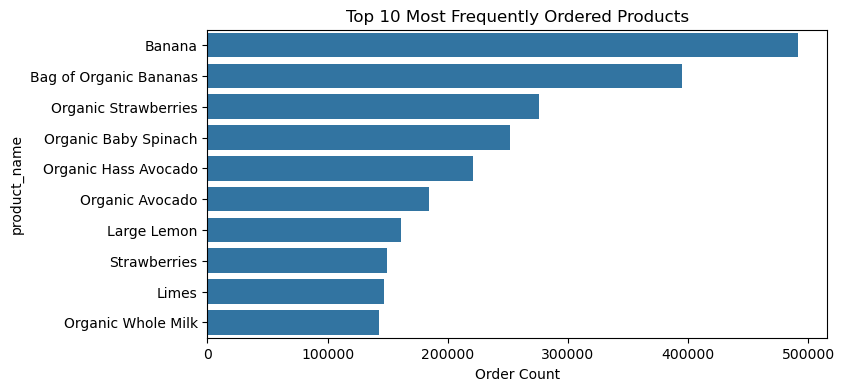

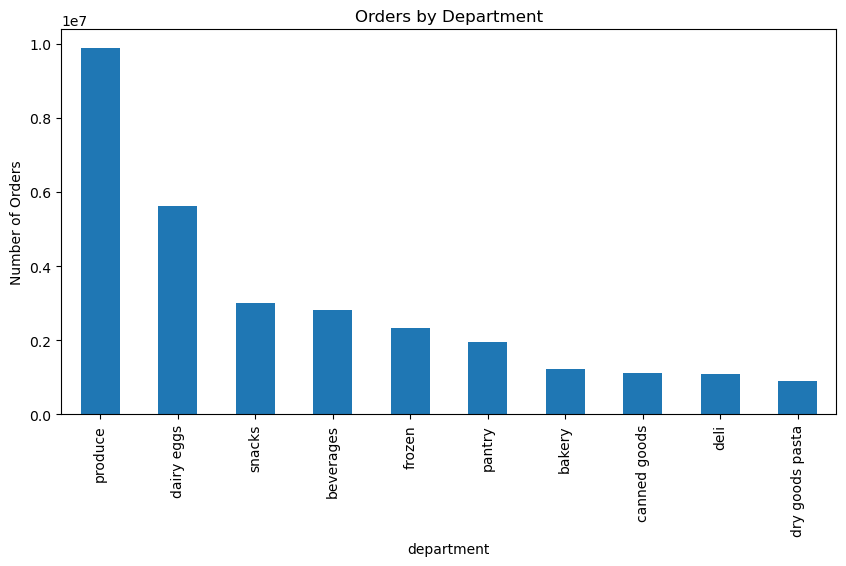

In [7]:
orders_per_user = df.groupby('user_id')['order_id'].nunique()
print(f"Average orders per user: {orders_per_user.mean():.2f}")

# Most popular products
top_products = df['product_name'].value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Most Frequently Ordered Products')
plt.xlabel('Order Count')
plt.show()

# Orders by department
plt.figure(figsize=(10,5))
df['department'].value_counts().head(10).plot(kind='bar')
plt.title('Orders by Department')
plt.ylabel('Number of Orders')
plt.show()


In [8]:
recency = orders.groupby('user_id')['days_since_prior_order'].sum().reset_index()
recency.columns = ['user_id', 'total_days_since_first_order']

# Frequency: number of orders
frequency = orders.groupby('user_id')['order_id'].nunique().reset_index()
frequency.columns = ['user_id', 'order_count']

# Merge metrics
rf = pd.merge(recency, frequency, on='user_id')
rf.describe()

,user_id,total_days_since_first_order,order_count
count,206209.000000,206209.000000,206209.000000
mean,103105.000000,173.284377,16.590367
std,59527.555167,100.998967,16.654774
min,1.000000,0.000000,4.000000
25%,51553.000000,89.000000,6.000000
50%,103105.000000,151.000000,10.000000
75%,154657.000000,254.000000,20.000000
max,206209.000000,365.000000,100.000000


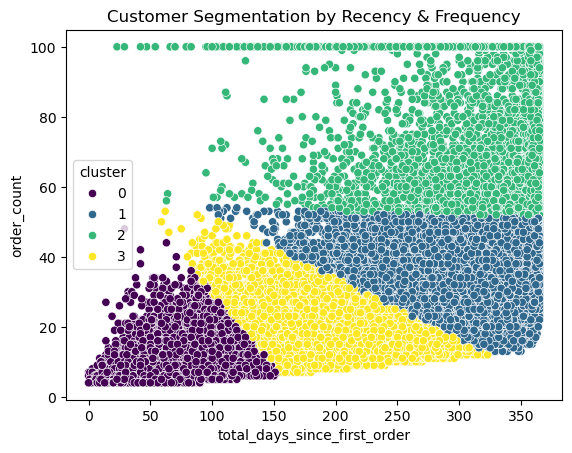

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = rf[['total_days_since_first_order', 'order_count']]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
rf['cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=rf, x='total_days_since_first_order', y='order_count', hue='cluster', palette='viridis')
plt.title("Customer Segmentation by Recency & Frequency")
plt.show()

In [14]:
basket = df[df['eval_set'] == 'prior']

TOP_N = 50

top_products = (
    basket['product_name']
    .value_counts()
    .head(TOP_N)
    .index
)

basket_filtered = basket[basket['product_name'].isin(top_products)]

print(f"Using top {TOP_N} products for analysis.")
print(f"Filtered dataset size: {basket_filtered.shape}")

# --- CREATE ORDER-PRODUCT MATRIX ---
basket_pivot = (
    basket_filtered.groupby(['order_id', 'product_name'])['reordered']
    .sum()
    .unstack(fill_value=0)
)

# Convert counts to binary flags (1 = purchased)
basket_pivot = basket_pivot.gt(0).astype(int)

print("Pivot table shape:", basket_pivot.shape)
print("Memory usage (MB):", round(basket_pivot.memory_usage().sum() / 1e6, 2))

freq_items = apriori(
    basket_pivot,
    min_support=0.01,
    use_colnames=True,
    verbose=1
)

print("Number of frequent itemsets found:", len(freq_items))

# Association rules
rules = association_rules(
    freq_items,
    metric="lift",
    min_threshold=1.0
).sort_values(by="lift", ascending=False)

rules.head(10)

rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules_display.head(10)

hi
you
are
here
Using top 50 products for analysis.
Filtered dataset size: (5373433, 15)
now
do we get here?
Pivot table shape: (2080697, 50)
Memory usage (MB): 848.92


/opt/anaconda3/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Processing 252 combinations | Sampling itemset size 32
Number of frequent itemsets found: 70


,antecedents,consequents,support,confidence,lift
37,(Organic Raspberries),(Organic Strawberries),0.012059,0.238035,2.406073
36,(Organic Strawberries),(Organic Raspberries),0.012059,0.121893,2.406073
21,(Banana),(Organic Fuji Apple),0.011946,0.062357,2.033281
20,(Organic Fuji Apple),(Banana),0.011946,0.389525,2.033281
4,(Organic Raspberries),(Bag of Organic Bananas),0.015101,0.298087,1.963286
5,(Bag of Organic Bananas),(Organic Raspberries),0.015101,0.099461,1.963286
2,(Organic Hass Avocado),(Bag of Organic Bananas),0.024002,0.293544,1.933371
3,(Bag of Organic Bananas),(Organic Hass Avocado),0.024002,0.158085,1.933371
34,(Organic Strawberries),(Organic Hass Avocado),0.014645,0.148029,1.810388
35,(Organic Hass Avocado),(Organic Strawberries),0.014645,0.179103,1.810388


Filtered to 2 strong rules.


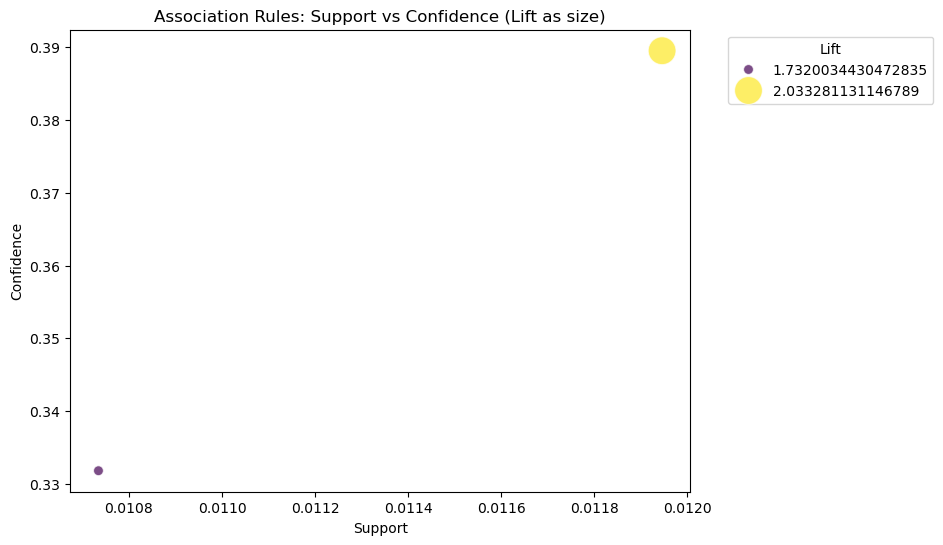

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

rules_filtered = rules[
    (rules['confidence'] > 0.3) &
    (rules['lift'] > 1.5)
].sort_values(by='lift', ascending=False)

print(f"Filtered to {len(rules_filtered)} strong rules.")
rules_filtered[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rules_filtered,
    x="support",
    y="confidence",
    size="lift",
    hue="lift",
    sizes=(50,400),
    alpha=0.7,
    palette="viridis"
)
plt.title("Association Rules: Support vs Confidence (Lift as size)")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.legend(title="Lift", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

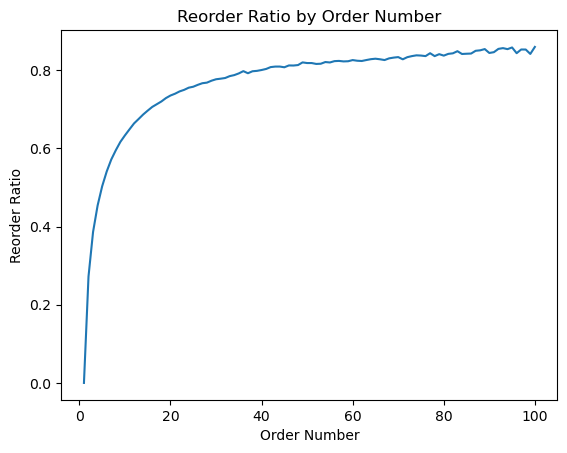

In [17]:
reorder_ratio = df.groupby('order_number')['reordered'].mean()
plt.plot(reorder_ratio)
plt.title('Reorder Ratio by Order Number')
plt.xlabel('Order Number')
plt.ylabel('Reorder Ratio')
plt.show()

/var/folders/pn/vy4zkm3503v200bgqgv32lk40000gn/T/ipykernel_8595/754274961.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


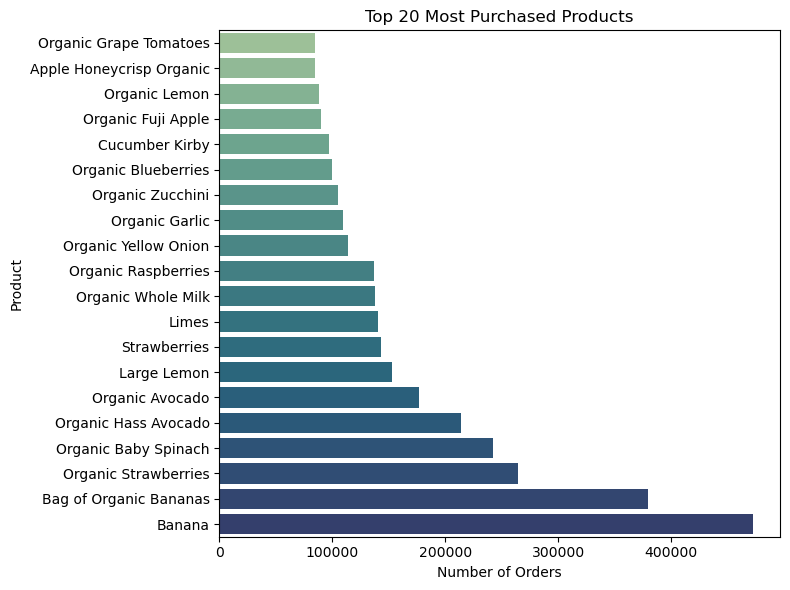

In [18]:

top_counts = (
    basket['product_name']
    .value_counts()
    .head(20)
    .sort_values(ascending=True)
)

plt.figure(figsize=(8,6))
sns.barplot(
    x=top_counts.values,
    y=top_counts.index,
    palette="crest"
)
plt.title("Top 20 Most Purchased Products")
plt.xlabel("Number of Orders")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

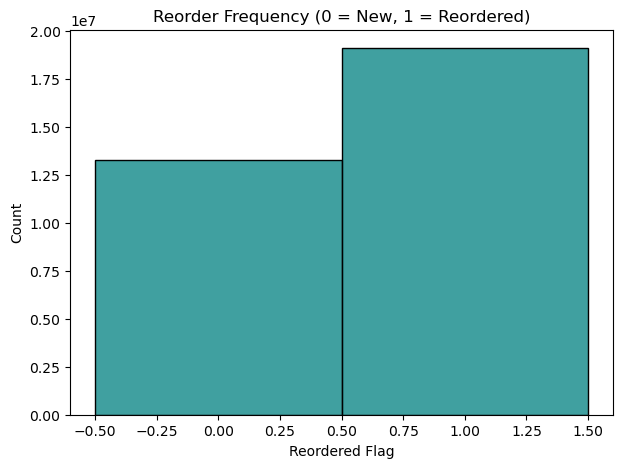

In [19]:
plt.figure(figsize=(7,5))
sns.histplot(basket['reordered'], bins=3, discrete=True, color="teal")
plt.title("Reorder Frequency (0 = New, 1 = Reordered)")
plt.xlabel("Reordered Flag")
plt.ylabel("Count")
plt.show()

/var/folders/pn/vy4zkm3503v200bgqgv32lk40000gn/T/ipykernel_8595/2106099730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


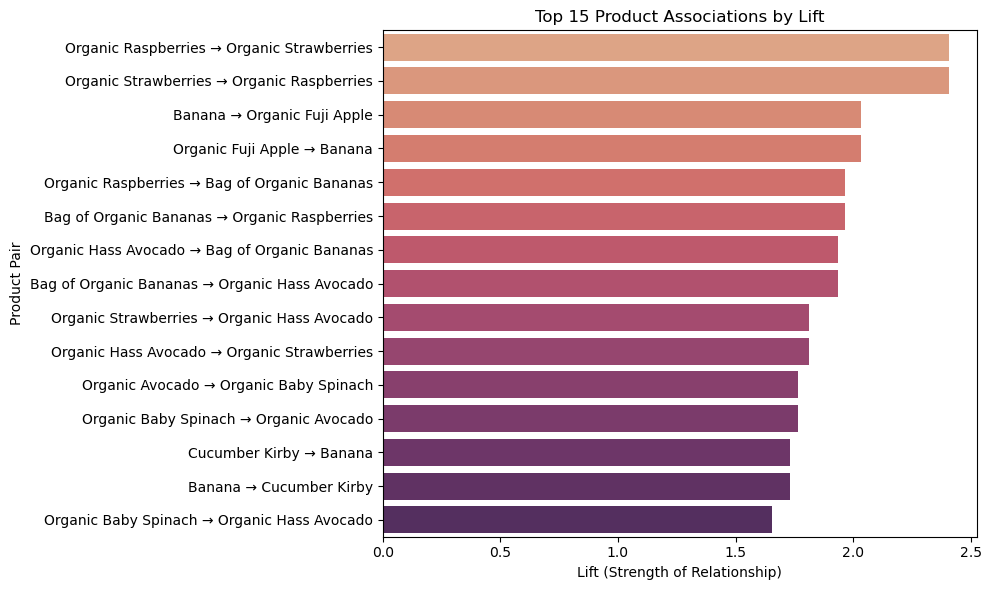

In [20]:
pair_rules = rules.copy()
pair_rules['pair'] = pair_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + " → " + pair_rules['consequents'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(10,6))
sns.barplot(
    y=pair_rules.head(15)['pair'],
    x=pair_rules.head(15)['lift'],
    palette="flare"
)
plt.title("Top 15 Product Associations by Lift")
plt.xlabel("Lift (Strength of Relationship)")
plt.ylabel("Product Pair")
plt.tight_layout()
plt.show()

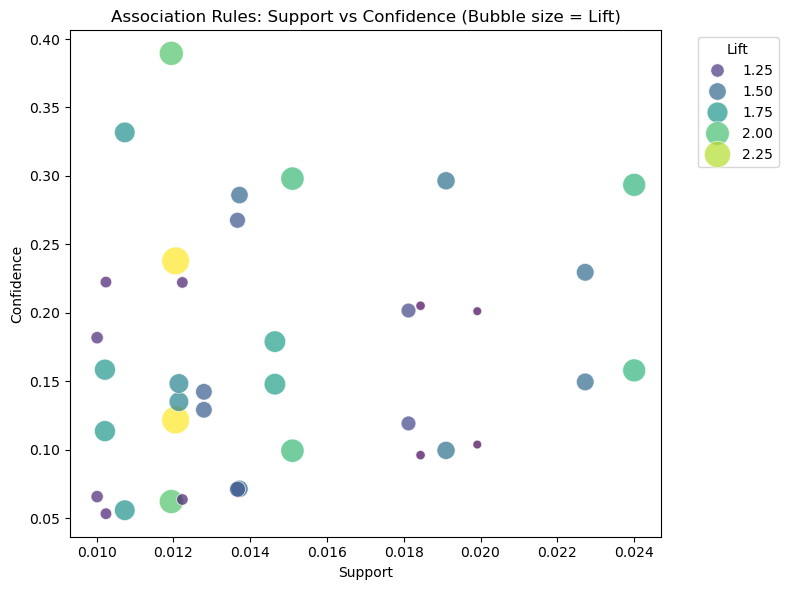

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rules,
    x='support',
    y='confidence',
    size='lift',
    hue='lift',
    sizes=(40, 400),
    alpha=0.7,
    palette='viridis'
)
plt.title("Association Rules: Support vs Confidence (Bubble size = Lift)")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.legend(title="Lift", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
# Merge datasets
data = (order_products_prior
        .merge(orders, on="order_id", how="left")
        .merge(products, on="product_id", how="left")
        .merge(aisles, on="aisle_id", how="left")
        .merge(departments, on="department_id", how="left"))

# Basic features
user_features = data.groupby('user_id').agg({
    'order_number': 'max',
    'days_since_prior_order': 'mean'
}).rename(columns={'order_number': 'total_orders', 'days_since_prior_order': 'avg_days_between_orders'})

product_features = data.groupby('product_id').agg({
    'reordered': 'mean',
    'add_to_cart_order': 'mean'
}).rename(columns={'reordered': 'product_reorder_rate', 'add_to_cart_order': 'avg_cart_position'})

# Combine
df = (data
      .merge(user_features, on='user_id', how='left')
      .merge(product_features, on='product_id', how='left'))

df = df[['user_id','product_id','order_dow','order_hour_of_day','avg_days_between_orders','product_reorder_rate','avg_cart_position','reordered']]
df.head()

,user_id,product_id,order_dow,order_hour_of_day,avg_days_between_orders,product_reorder_rate,avg_cart_position,reordered
0,202279,33120,5,9,19.433333,0.708454,6.816959,1
1,202279,28985,5,9,19.433333,0.694465,7.501683,1
2,202279,9327,5,9,19.433333,0.157962,9.943166,0
3,202279,45918,5,9,19.433333,0.272849,8.444892,1
4,202279,30035,5,9,19.433333,0.507909,8.481547,0


In [ ]:

from sklearn.model_selection import train_test_split
print("yay")
from sklearn.ensemble import RandomForestClassifier
print("this")
from sklearn.metrics import classification_report, confusion_matrix
print("worked")
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [ ]:
# First, identify categorical columns
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col != 'reordered']
numeric_cols = [col for col in df.columns if df[col].dtype != 'object' and col != 'reordered']

# Create preprocessor to handle categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # This will pass through the numeric columns
)

# Create the pipeline with preprocessing and model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])


In [ ]:
X = df.drop('reordered', axis=1)
y = df['reordered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use the pipeline instead of just the model
X_train_small = X_train.sample(10000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

pipeline.fit(X_train_small, y_train_small)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))